<h3>Epileptic Seizure Detection

Data source: https://archive.ics.uci.edu/dataset/1134/beed:+bangalore+eeg+epilepsy+dataset

In [ ]:
from pathlib import Path
PROJ_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
RAW_DATA_PATH = RAW_DATA_DIR / "BEED_Data.csv"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
raw_data = pd.read_csv(RAW_DATA_PATH)
raw_data.head(20)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0
5,-47,-52,-45,-41,-29,-24,-21,-19,-13,-3,-2,4,11,14,11,14,0
6,-67,-30,7,33,51,79,105,122,132,115,83,42,10,-22,-47,-57,0
7,72,60,67,69,55,46,30,23,31,40,51,54,65,69,60,50,0
8,56,14,-12,-38,-73,-115,-137,-130,-78,-18,33,85,132,196,244,258,0
9,-17,-16,-12,13,53,84,77,57,24,-20,-39,-45,-40,-35,-19,-4,0


- X1 - X16 are the EEG instrument channels corresponding to different brain regions.
- y is a value indicating from 0 to 3:
    - 3 – Recording of seizure events (including activities such as eye blinking or constant staring)
    - 2 – Recording of focal seizures
    - 1 – Recording of generalized seizures
    - 0 – Recording of healthy subjects (control group without epileptic seizures)

- Each row is a single 20-second recording

In [ ]:
raw_data['y'].nunique()
# Multiclass target

4

In [ ]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      8000 non-null   int64
 1   X2      8000 non-null   int64
 2   X3      8000 non-null   int64
 3   X4      8000 non-null   int64
 4   X5      8000 non-null   int64
 5   X6      8000 non-null   int64
 6   X7      8000 non-null   int64
 7   X8      8000 non-null   int64
 8   X9      8000 non-null   int64
 9   X10     8000 non-null   int64
 10  X11     8000 non-null   int64
 11  X12     8000 non-null   int64
 12  X13     8000 non-null   int64
 13  X14     8000 non-null   int64
 14  X15     8000 non-null   int64
 15  X16     8000 non-null   int64
 16  y       8000 non-null   int64
dtypes: int64(17)
memory usage: 1.0 MB


So far it seems like a fairly simple dataset in terms of datatypes (all integers). There also appears to be no null or missing values:

In [ ]:
raw_data.isna().any(axis=1).sum()
# Returns 0

np.int64(0)

No imputation will be required in this case. The hardest part of this will likely be the feature selection.

N.B. 
- The only conversion/encoding that will be needed here will be on the target ('y'). It looks like there is some ordering when comparing 3,2, and 1 (seizure events) to 0 (no seizure events), but no apparent ordering when comparing 3, 2 and 1 with eachother. Will consider a nominal encoding technique over an ordinal one.
- I could add a new feature which is binary, where 0 is no seizure and 1 is any type of seizure, computed from 'y' A downside to this may be the introduction of class imbalance which would required the introduction of sampling techniques into the pipeline. The target will however become ordinal.



<h4>EDA

*Distribution and Outlier Analysis*

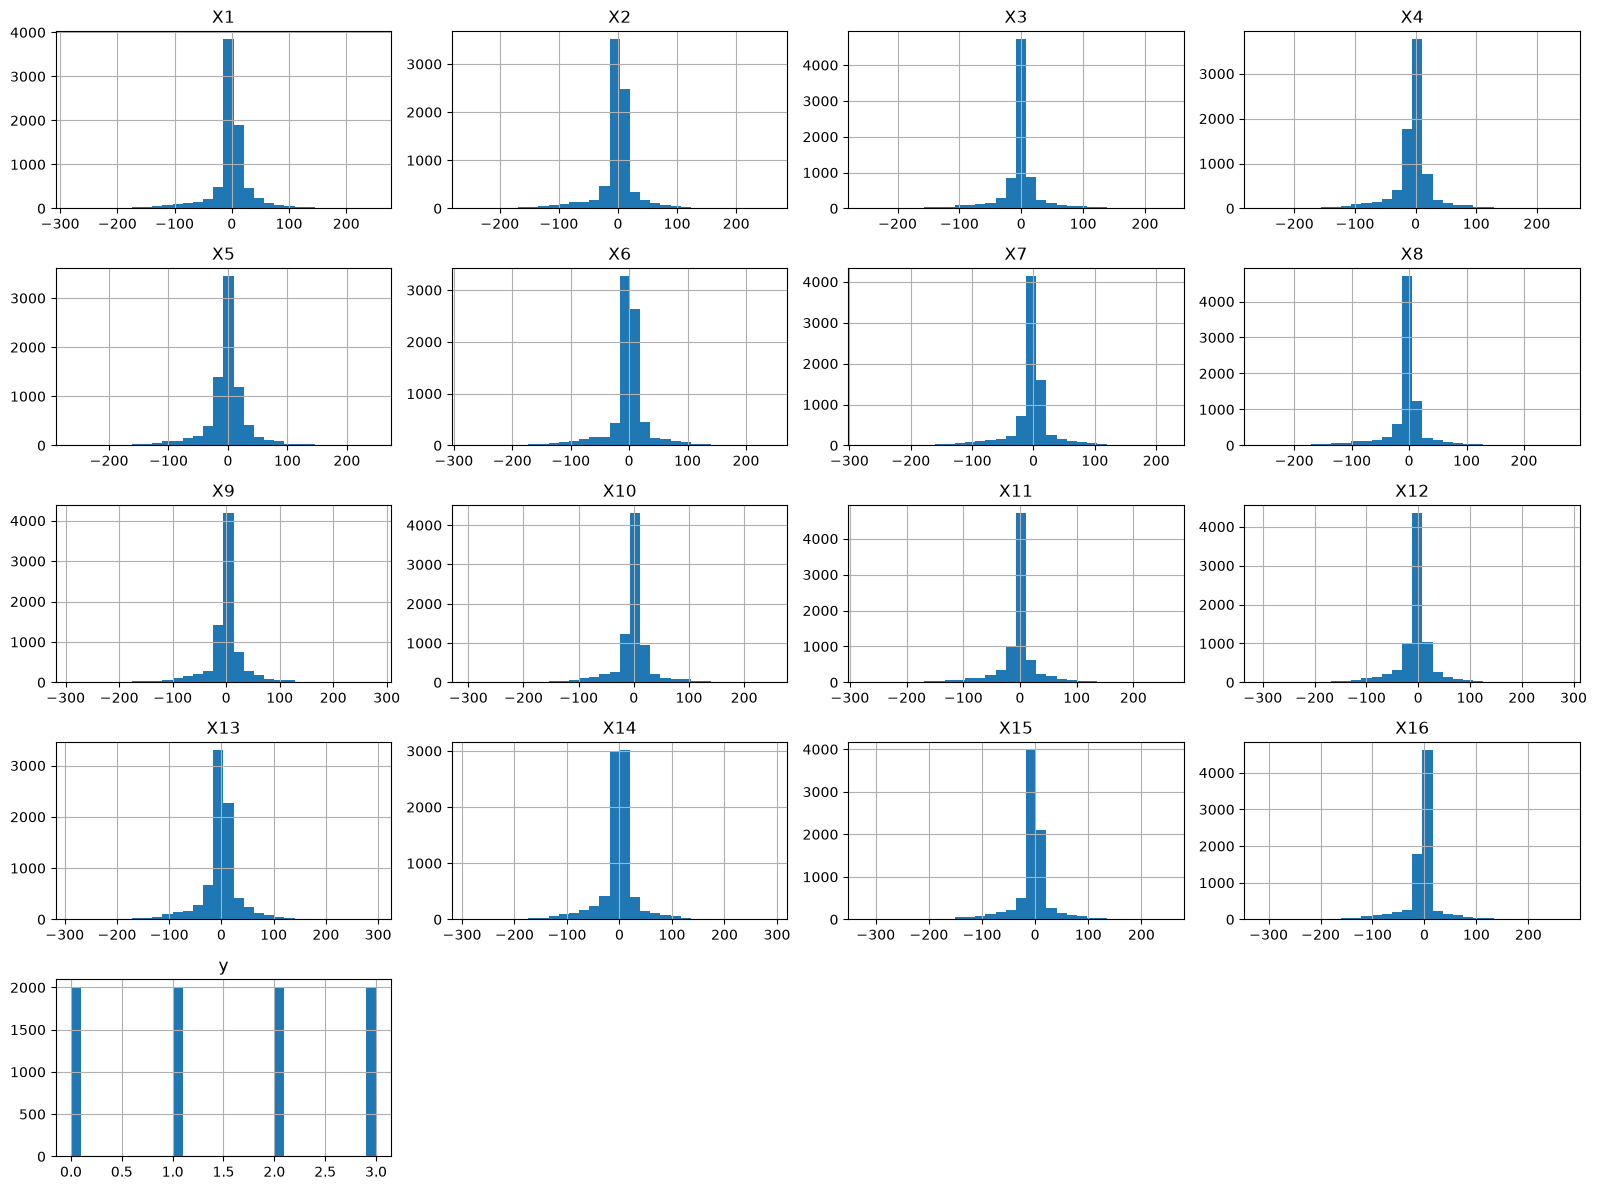

In [ ]:
raw_data.hist(figsize=(16, 12), layout=(5, 4), bins=30)
plt.tight_layout()

Observations:
- Very balanced target class 'y'. Appears to be 25% for each of the 4 classes. If I were to make this a binary classification problem as described in the previous section by creating a new binary target of seizure presence (1), or no-seizure presence (0), class imbalance would be introduced (at a 3:1 ratio)
- The feature columns seem to have mean values of around 0. Hard to spot outliers here visually so will need to double check outlier presence using other techniques.

In [ ]:
import seaborn as sns

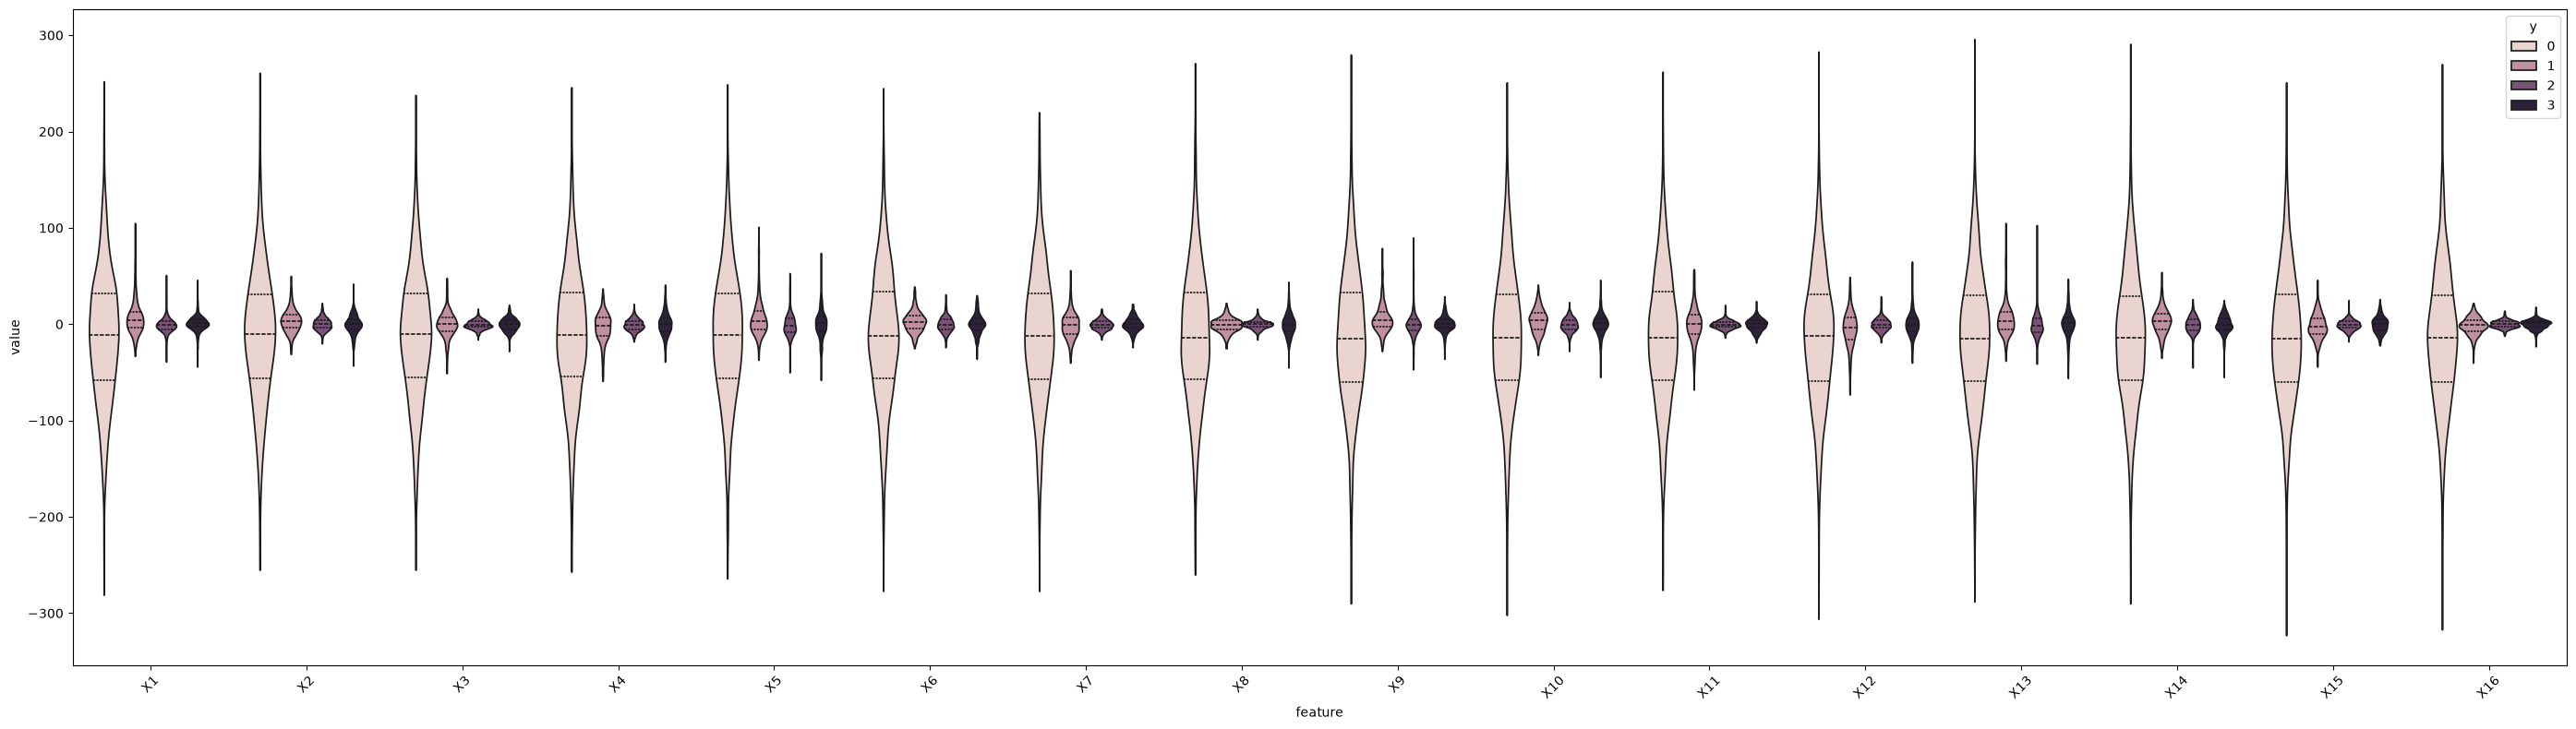

In [ ]:
# Violin plots by class for each feature
plot_df = raw_data.melt(id_vars='y', var_name='feature', value_name='value')
plt.figure(figsize=(28, 8))
sns.violinplot(data=plot_df, x='feature', y='value', hue='y', cut=0, inner='quartile')
plt.xticks(rotation=45)
plt.tight_layout()

The violin plots appear to show a fairly evenly distrubuted set of values for each of the features as a function of the target class as shown by the 'even' shapes of the violins.

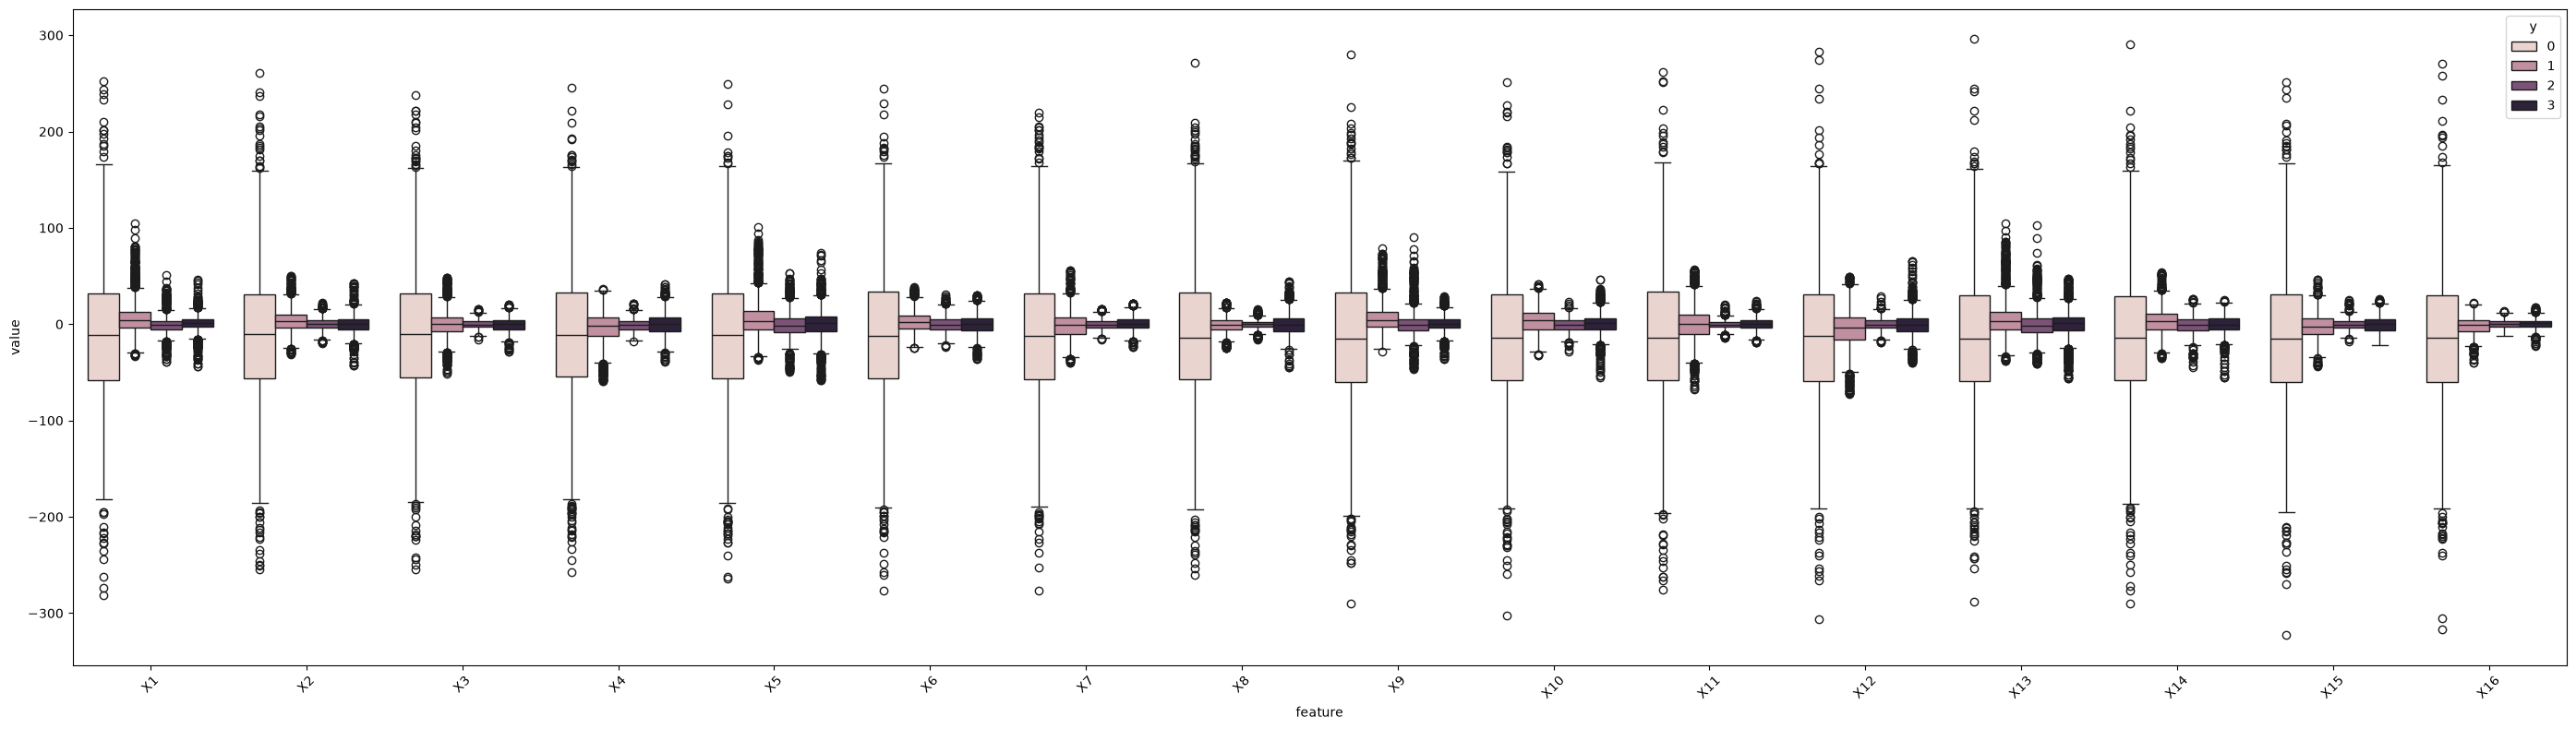

In [ ]:
# Boxplots by class for each feature
plot_df = raw_data.melt(id_vars='y', var_name='feature', value_name='value')
plt.figure(figsize=(28, 8))
sns.boxplot(data=plot_df, x='feature', y='value', hue='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# By default, the 'threshold' of outlier detemination is 2.7x s.d. from the mean (Turkey's rule).

Based on the default 

Compute Z-scores to detect any outliers numerically (using threshold of Z = 3)

In [ ]:
from scipy.stats import zscore

numeric_columns = raw_data.select_dtypes(include=np.number).columns.drop('y', errors='ignore')
X_numeric = raw_data[numeric_columns]

threshold = 3
z_scores = np.abs(zscore(X_numeric))
outliers_mask = (z_scores > threshold)

outlier_counts = pd.DataFrame({
    'feature': numeric_columns,
    'outlier_count': outliers_mask.sum(axis=0),
    'percentage': (outliers_mask.sum(axis=0) / len(X_numeric)) * 100
})

print(outlier_counts)

   feature  outlier_count  percentage
0       X1            229      2.8625
1       X2            233      2.9125
2       X3            239      2.9875
3       X4            227      2.8375
4       X5            211      2.6375
5       X6            236      2.9500
6       X7            234      2.9250
7       X8            245      3.0625
8       X9            223      2.7875
9      X10            227      2.8375
10     X11            225      2.8125
11     X12            218      2.7250
12     X13            197      2.4625
13     X14            218      2.7250
14     X15            223      2.7875
15     X16            238      2.9750


Not too many outliers present. Only ~3%